In [151]:
# Acquire normalization information
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from scipy.optimize import curve_fit
import pandas as pd

In [191]:
# Normalizing per LOR
name = 'hcirc_pcut_a'
path = f'/home/kale-chen/Documents/PET/MDA_03162026/Data/{name}.bin'
num_cols = 3
data_type = np.int16
num_rows = os.path.getsize(path) // (num_cols * data_type().itemsize)
data1 = np.memmap(path, dtype = data_type, mode = 'r', shape = (num_rows, num_cols))
event_counts = np.zeros((3072, 3072), dtype = np.int32)
for i in tqdm(range(0, num_rows, 1000000), desc=''):
    chunk = data1[i:i+1000000]
    if num_cols == 3:
        idls = np.asarray(chunk[:, 0], dtype = np.int32)
        idrs = np.asarray(chunk[:, 1], dtype = np.int32)
        np.add.at(event_counts, (idls, idrs), 1)
    else:
        idls = np.asarray(chunk[:, 1], dtype = np.int32)
        idrs = np.asarray(chunk[:, 3], dtype = np.int32)
        np.add.at(event_counts, (idls, idrs), 1)
print(np.sum(event_counts))
with open('eventcountsh.txt', 'w') as f:
    for i in range(3072):
        f.write(str(np.sum(event_counts[i, :])) + '\n')
    for i in range(3072):
        f.write(str(np.sum(event_counts[:, i])) + '\n')
#event_counts[event_counts == 0] = np.max(event_counts.flatten())
event_counts[event_counts == 0] = 1
norm_factors = 1 / event_counts
norm_factors = norm_factors / np.median(norm_factors)
norm_factors = norm_factors.astype(np.float32)
norm_factors.tofile('norm_factors1.bin')

100%|██████████| 52/52 [00:03<00:00, 14.58it/s]


51037628


In [192]:
# Normalizing per channel
geometriccorrection = False

name = 'hcirc_pcut_a'
path = f'/home/kale-chen/Documents/PET/MDA_03162026/Data/{name}.bin'
num_cols = 3
data_type = np.int16
num_rows = os.path.getsize(path) // (num_cols * data_type().itemsize)
data1 = np.memmap(path, dtype = data_type, mode = 'r', shape = (num_rows, num_cols))
eventcounts = np.zeros((3072 * 2), dtype = np.int32)
for i in tqdm(range(0, num_rows, 1000000), desc='Event counts'):
    chunk = data1[i:i+1000000]
    idls = np.asarray(chunk[:, 0], dtype = np.int32)
    idls = idls + 3072
    idrs = np.asarray(chunk[:, 1], dtype = np.int32)
    np.add.at(eventcounts, idls, 1)
    np.add.at(eventcounts, idrs, 1)
norm_factors = np.zeros((3072, 3072), dtype = np.float32)
if geometriccorrection:
    mapdf = pd.read_csv('/home/kale-chen/Documents/PET/TPPT_Scanner_map_adjusted.csv', header = None)
    coords = np.asarray(mapdf.iloc[:, 0:3], dtype = np.float32)
    directions = np.asarray(mapdf.iloc[:, 3:6], dtype = np.float32)
def get_geommetric_correction(idl, idr): # Get the cosine of the relative angle between two crystals
    lor_vector = coords[idr] - coords[idl]
    lor_vector = lor_vector / np.linalg.norm(lor_vector) # Normalize
    cosidl = np.dot(directions[idl], lor_vector)
    cosidr = np.dot(directions[idr], lor_vector)
    return np.abs(cosidl * cosidr)

for idl in tqdm(range(3072), desc='Normalizing'):
    for idr in range(3072):
        if geometriccorrection:
            norm_factors[idl, idr] = eventcounts[idl + 3072] * eventcounts[idr] * get_geommetric_correction(idl + 3072, idr)
        else:
            norm_factors[idl, idr] = eventcounts[idl + 3072] * eventcounts[idr]
#norm_factors[norm_factors == 0] = np.max(norm_factors.flatten())
norm_factors[norm_factors == 0] = 1
norm_factors = 1 / norm_factors
norm_factors = norm_factors / np.mean(norm_factors)
norm_factors = norm_factors.astype(np.float32)
norm_factors.tofile('norm_factors_ch1.bin')


Normalizing: 100%|██████████| 3072/3072 [00:02<00:00, 1282.61it/s]


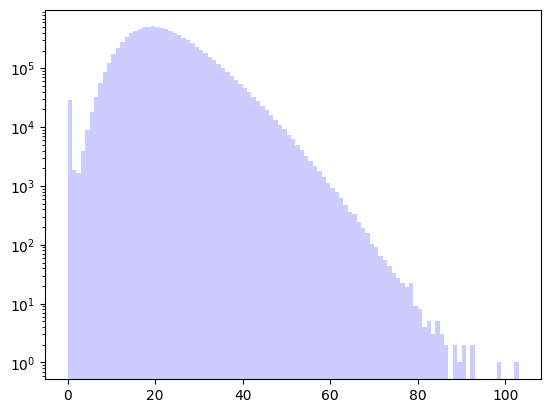

In [71]:
hist = plt.hist(event_counts.flatten(), bins = np.max(event_counts.flatten()), color = 'blue', alpha = 0.2)[0]
plt.yscale('log')
plt.show()

In [180]:
# Apply normalization to other run

name = 'mcirc_pcut_a'
path = f'/home/kale-chen/Documents/PET/MDA_03162026/Data/{name}.bin'
num_cols = 3
data_type = np.int16
num_rows = os.path.getsize(path) // (num_cols * data_type().itemsize)
data1 = np.memmap(path, dtype = data_type, mode = 'r', shape = (num_rows, num_cols))
event_counts1 = np.zeros((3072, 3072), dtype = np.int32)
for i in tqdm(range(0, num_rows, 1000000), desc=''):
    chunk = data1[i:i+1000000]
    if num_cols == 3:
        idls = np.asarray(chunk[:, 0], dtype = np.int32)
        idrs = np.asarray(chunk[:, 1], dtype = np.int32)
        np.add.at(event_counts1, (idls, idrs), 1)
    else:
        idls = np.asarray(chunk[:, 1], dtype = np.int32)
        idrs = np.asarray(chunk[:, 3], dtype = np.int32)
        np.add.at(event_counts1, (idls, idrs), 1)
#event_counts_normalized = event_counts1 * event_counts_norm
event_counts_normalized = event_counts1 * norm_factors

100%|██████████| 44/44 [00:02<00:00, 18.27it/s]


0.8513518104720698


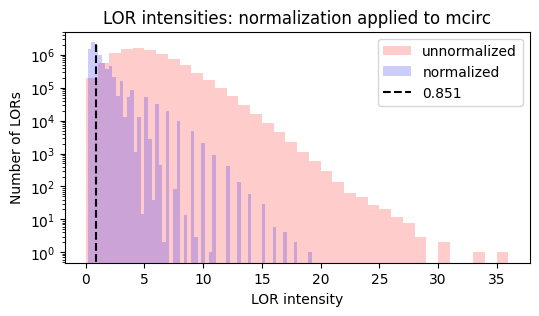

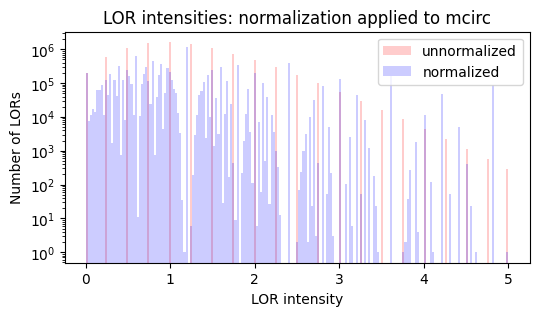

In [165]:
bins = np.linspace(0, 30, 100)
bincenters = (bins[1:] + bins[:-1]) / 2
plt.figure(0, figsize = (6, 3))
plt.hist(event_counts1.flatten(), bins = 36, color = 'red', alpha = 0.2, label = 'unnormalized')
hist = plt.hist(event_counts_normalized.flatten(), bins = bincenters, color = 'blue', alpha = 0.2, label = 'normalized')[0]
expectedmean = np.sum(event_counts1) / 51037628
print(expectedmean)
plt.vlines(expectedmean, 0, np.max(hist), color = 'black', linestyle = '--', label = round(expectedmean, 3))

plt.yscale('log')
plt.title('LOR intensities: normalization applied to mcirc')
plt.xlabel('LOR intensity')
plt.ylabel('Number of LORs')
plt.legend()

plt.figure(1, figsize = (6, 3))
event_counts1_stm = event_counts1 / np.median(event_counts1)
event_counts_normalized_stm = event_counts_normalized / np.median(event_counts_normalized)
bins = np.linspace(0, 5, 200)
plt.hist(event_counts1_stm.flatten(), bins = bins, color = 'red', alpha = 0.2, label = 'unnormalized')
plt.hist(event_counts_normalized_stm.flatten(), bins = bins, color = 'blue', alpha = 0.2, label = 'normalized')
plt.legend()
plt.yscale('log')
plt.title('LOR intensities: normalization applied to mcirc')
plt.xlabel('LOR intensity')
plt.ylabel('Number of LORs')
plt.show()


0.0


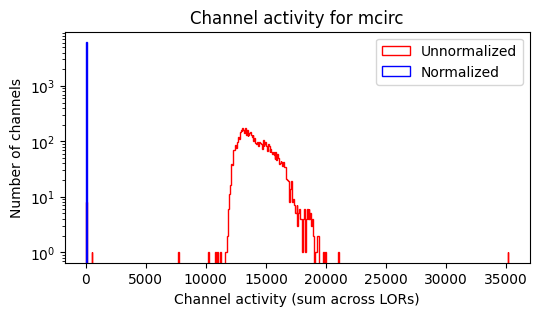

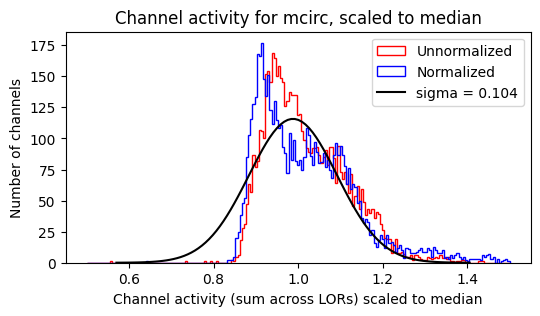

In [181]:
channel_counts = np.zeros(3072*2, dtype = np.float32)
channel_counts_norm = np.zeros(3072*2, dtype = np.float32)
for i in range(3072):
    channel_counts[i] = np.sum(event_counts1[i, :])
    channel_counts[3072 + i] = np.sum(event_counts1[:, i])
    channel_counts_norm[i] = np.sum(event_counts_normalized[i, :])
    channel_counts_norm[3072 + i] = np.sum(event_counts_normalized[:, i])

plt.figure(0, figsize = (6, 3))
bins = np.linspace(0, np.max(channel_counts), 500)
plt.hist(channel_counts, bins = bins, color = 'red', label = 'Unnormalized', histtype = 'step', linewidth = 1)
hist, bins = plt.hist(channel_counts_norm, bins = bins, color = 'blue', label = 'Normalized', histtype = 'step', linewidth = 1)[0:2]
plt.legend()
plt.yscale('log')
plt.xlabel('Channel activity (sum across LORs)')
plt.ylabel('Number of channels')
plt.title('Channel activity for mcirc')
print(bins[np.argmax(hist)])


with open('eventcountsm.txt', 'w') as f:
    for i in range(3072*2):
        f.write(str(channel_counts[i]) + '\n')
with open('eventcountsmnorm.txt', 'w') as f:
    for i in range(3072*2):
        f.write(str(channel_counts_norm[i]) + '\n')


plt.figure(1, figsize = (6, 3))

channel_counts = channel_counts / np.median(channel_counts)
channel_counts_norm = channel_counts_norm / np.median(channel_counts_norm)
bins = np.linspace(0.5, 1.5, 200)
plt.hist(channel_counts, bins = bins, color = 'red', label = 'Unnormalized', histtype = 'step', linewidth = 1)
hist, bins = plt.hist(channel_counts_norm, bins = bins, color = 'blue', label = 'Normalized', histtype = 'step', linewidth = 1)[0:2]
def gaussian(x, a, mu, sigma):
    return a * np.exp(-(x - mu)**2 / (2 * sigma**2))
bincenters = (bins[1:] + bins[:-1]) / 2
popt, _ = curve_fit(gaussian, bincenters, hist)
plotting_bounds = np.linspace(popt[1] - 4 * popt[2], popt[1] + 4 * popt[2], 100)
plt.plot(plotting_bounds, gaussian(plotting_bounds, *popt), color = 'black', label = f'sigma = {np.abs(popt[2]):.3f}')


plt.legend()
#plt.yscale('log')
plt.xlabel('Channel activity (sum across LORs) scaled to median')
plt.ylabel('Number of channels')
plt.title('Channel activity for mcirc, scaled to median')
plt.show()




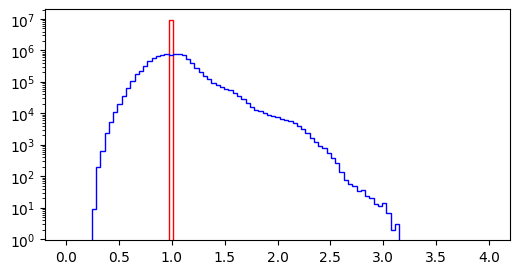

In [184]:
# Compare two norm methods
norm1 = np.fromfile('norm_factors_ch.bin', dtype = np.float32)
norm2 = np.fromfile('norm_factors_ch_geom.bin', dtype = np.float32)
norm3 = np.fromfile('norm_factors_ch_center.bin', dtype = np.float32)

ratios = norm1 / norm2
ratios = ratios / np.median(ratios)
plt.figure(0, figsize = (6, 3))
bins = np.linspace(0, 4, 100)
plt.hist(ratios.flatten(), bins = bins, color = 'red', histtype = 'step', linewidth = 1)
ratios2 = norm1 / norm3
ratios2 = ratios2 / np.median(ratios2)
plt.hist(ratios2.flatten(), bins = bins, color = 'blue', histtype = 'step', linewidth = 1)
plt.yscale('log')
plt.show()



100%|██████████| 3072/3072 [00:00<00:00, 69608.23it/s]


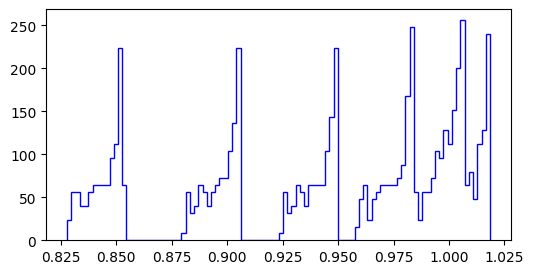

In [ ]:
# Expected distribution of channel activity with simple geometric assumption

# Assume LOR activity is proportional to the cosine product of the crystal directions against the LOR
mapdf = pd.read_csv('/home/kale-chen/Documents/PET/TPPT_Scanner_map_adjusted.csv', header = None)
coords = np.asarray(mapdf.iloc[:, 0:3], dtype = np.float32)
directions = np.asarray(mapdf.iloc[:, 3:6], dtype = np.float32)
def get_geommetric_correction(idl, idr): # Get the cosine of the relative angle between two crystals
    lor_vector = coords[idr] - coords[idl]
    lor_vector = lor_vector / np.linalg.norm(lor_vector) # Normalize
    cosidl = np.dot(directions[idl], lor_vector)
    cosidr = np.dot(directions[idr], lor_vector)
    return np.abs(cosidl * cosidr)

expectedintensity = np.zeros((3072, 3072), dtype = np.float32)
for i in tqdm(range(3072)):
    for j in range(3072):
        expectedintensity[i, j] = get_geommetric_correction(i + 3072, j)
expectedintensity = expectedintensity / np.median(expectedintensity)
expectedintensityperchannel = np.zeros(3072*2, dtype = np.float32)
for i in tqdm(range(3072)):
    expectedintensityperchannel[i] = np.sum(expectedintensity[i, :]) / 3072
    expectedintensityperchannel[i + 3072] = np.sum(expectedintensity[:, i]) / 3072


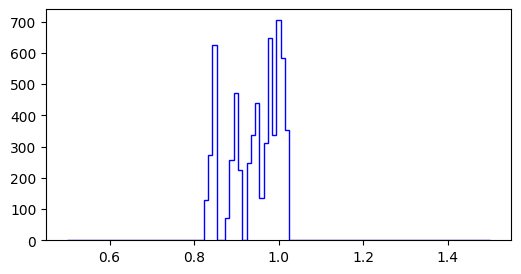

In [178]:
plt.figure(0, figsize = (6, 3))
bins = np.linspace(0.5, 1.5, 100)
plt.hist(expectedintensityperchannel.flatten(), bins = bins, color = 'blue', histtype = 'step', linewidth = 1)
plt.show()